Praca z danymi i GitHub

Instrukcje:
Przprowadz analizy danych na podstawie pliku z załącznika, zwróć uwagę na typ załączonego pliku - czym go otworzysz (zwróć uwagę, że plik ma wiele zakładek)?

projekt_data_science_szablon.md

W moich danych mam listę zakupów danego dnia w danej kategorii podzieloną na płeć konsumenta, ilość kupionego towaru, jego cenę oraz całkowity koszt rachunku

Chciałbym się dowiedzieć, czy w kolejnych miesiącach więcej na zakupy wydadzą mężczyźni czy kobiety. Wydaje mi się, że poprawną odpowiedzią będą kobiety, które wydadzą pieniądze głównie na produkty 'Beauty' i 'Clothing'.

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, confusion_matrix


## 1. Import i wczytanie danych

In [66]:
df_csv = pd.read_csv('SalesDataset.csv')
df = df_csv.copy().drop(columns=['Unnamed: 0'])

# Konwersja daty - ważne dla hipotezy o miesiącach
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Month_Year'] = df['Date'].dt.to_period('M').astype(str)

df.head()

,Date,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Month_Year
0,2023-11-24,Male,34,Beauty,3,50,150,11,2023-11
1,2023-02-27,Female,26,Clothing,2,500,1000,2,2023-02
2,2023-01-13,Male,50,Electronics,1,30,30,1,2023-01
3,2023-05-21,Male,37,Clothing,1,500,500,5,2023-05
4,2023-05-06,Male,30,Beauty,2,50,100,5,2023-05


## 2. Pierwsze spojrzenie na dane

In [67]:
# Kształt danych (liczba wierszy i kolumn)
print(df.shape)
# Informacje o typach danych i brakach
df.info()
# Statystyki opisowe
df.describe(include="all")
# Liczba braków w każdej kolumnie
df.isna().sum()

(1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1000 non-null   datetime64[ns]
 1   Gender            1000 non-null   object        
 2   Age               1000 non-null   int64         
 3   Product Category  1000 non-null   object        
 4   Quantity          1000 non-null   int64         
 5   Price per Unit    1000 non-null   int64         
 6   Total Amount      1000 non-null   int64         
 7   Month             1000 non-null   int32         
 8   Month_Year        1000 non-null   object        
dtypes: datetime64[ns](1), int32(1), int64(4), object(3)
memory usage: 66.5+ KB


Date                0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
Month               0
Month_Year          0
dtype: int64

Komentarz:

Mam 1000 obserwacji (wierszy) i 8 cech

Ważne cechy to: płeć, kategoria produktu, całkowita kwota

Brak braków danych, dobrą docelową zmienną będzie 'Total Amount'

## 3. EDA: rozkłady, outliery, korelacje

Index(['Age', 'Quantity', 'Price per Unit', 'Total Amount'], dtype='object')


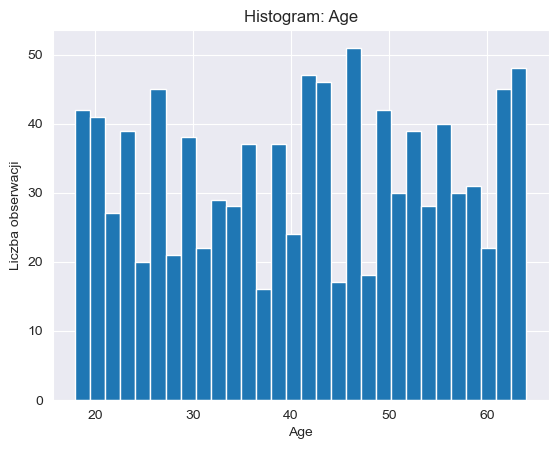

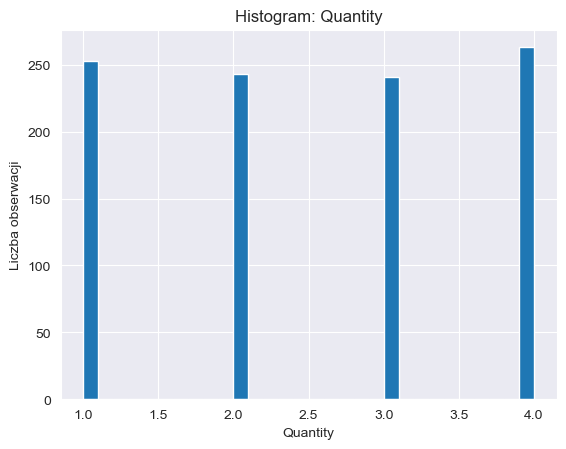

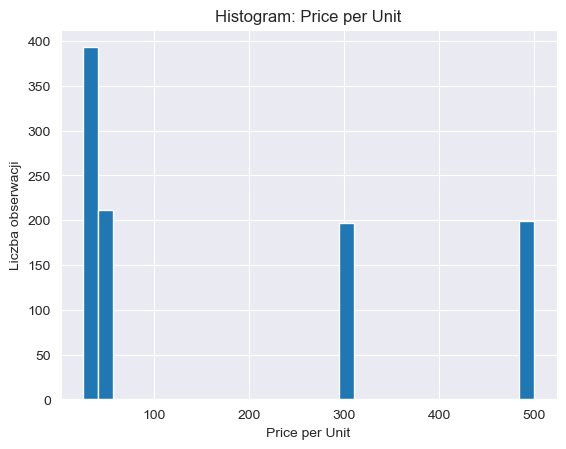

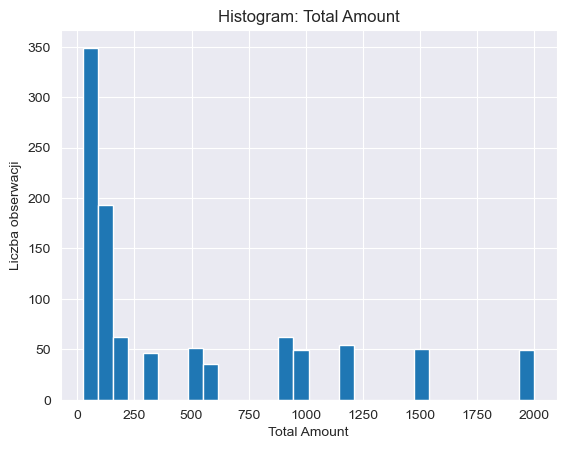

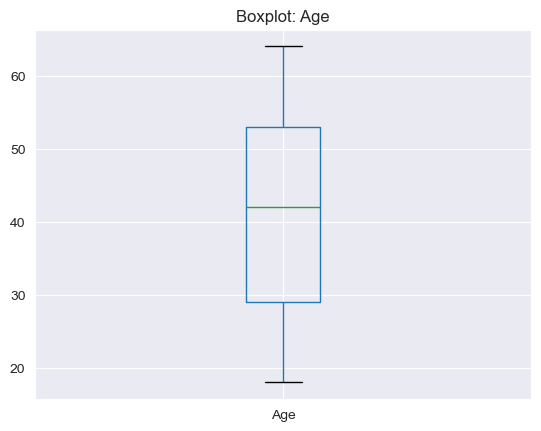

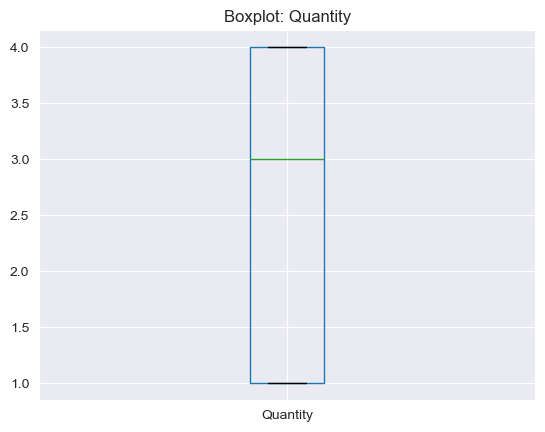

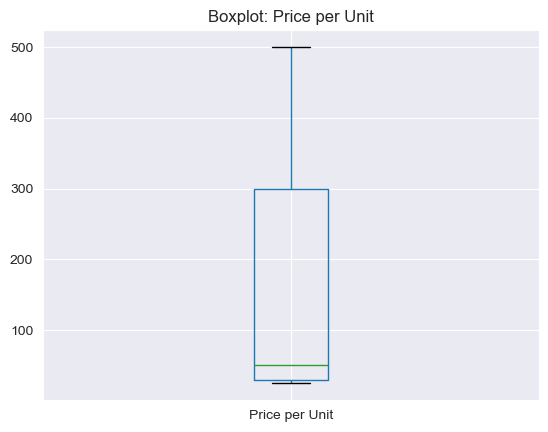

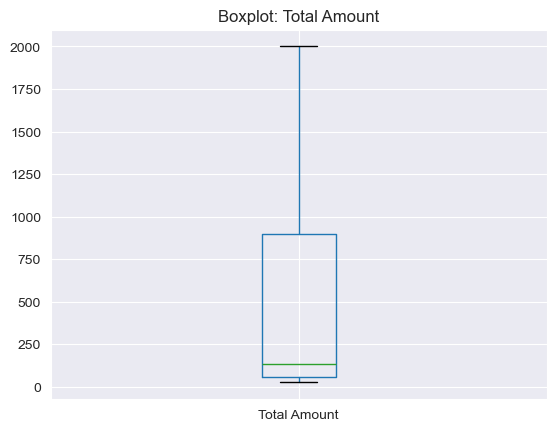

Obliczone korelacje:
                     Age  Quantity  Price per Unit  Total Amount     Month
Age             1.000000 -0.023737       -0.038423     -0.060568 -0.000640
Quantity       -0.023737  1.000000        0.017501      0.373707 -0.021803
Price per Unit -0.038423  0.017501        1.000000      0.851925 -0.008161
Total Amount   -0.060568  0.373707        0.851925      1.000000 -0.005197
Month          -0.000640 -0.021803       -0.008161     -0.005197  1.000000


In [68]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
print(numeric_cols)

for col in numeric_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Liczba obserwacji")
    plt.show()

for col in numeric_cols:
    plt.figure()
    df.boxplot(column=col)
    plt.title(f"Boxplot: {col}")
    plt.show()

print("Obliczone korelacje:")
corr = df.corr(numeric_only=True)
print(corr)

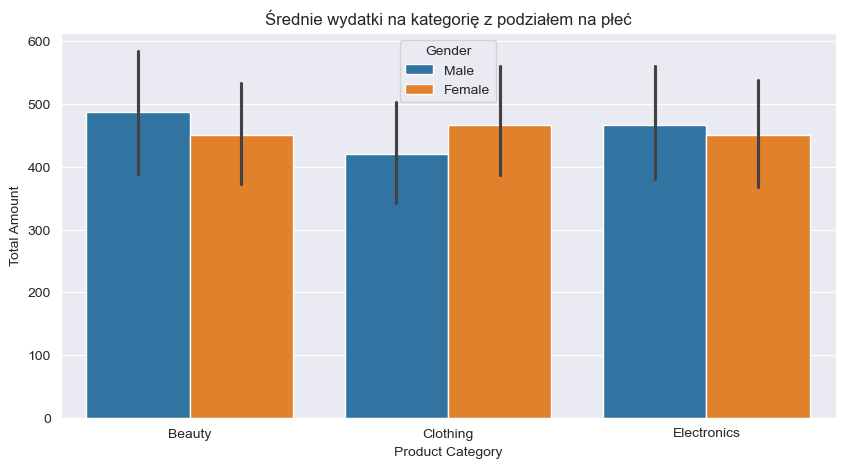

In [69]:
# Średnie wydatki według płci i kategorii
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Product Category', y='Total Amount', hue='Gender')
plt.title("Średnie wydatki na kategorię z podziałem na płeć")
plt.show()

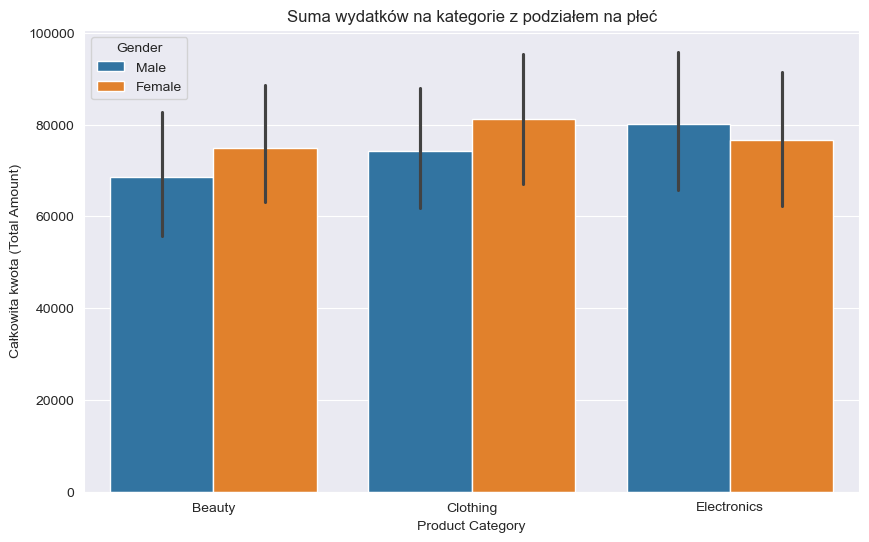

In [70]:
# Suma wydatków wg kategorii i płci
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Product Category', y='Total Amount', hue='Gender', estimator=sum)
plt.title("Suma wydatków na kategorie z podziałem na płeć")
plt.ylabel("Całkowita kwota (Total Amount)")
plt.show()

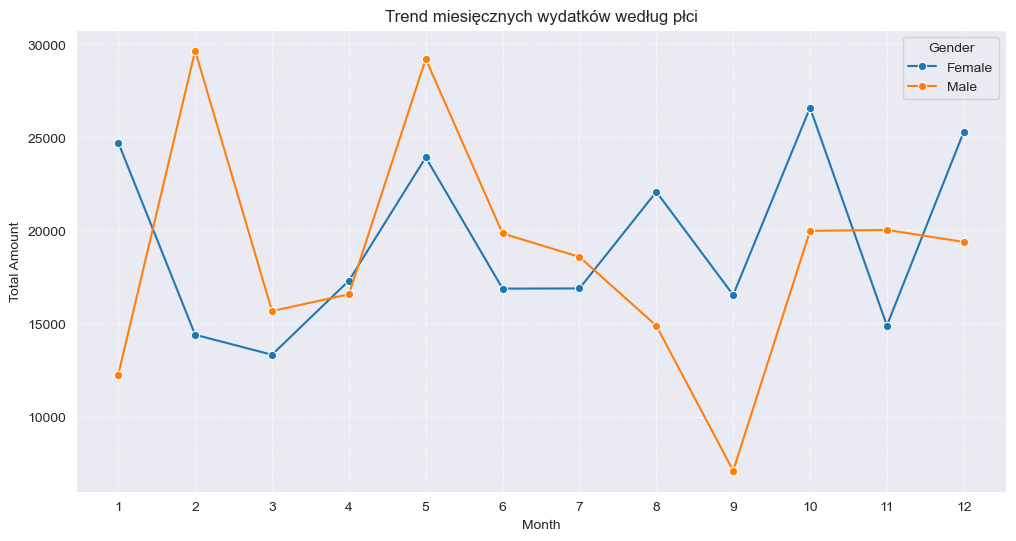

In [71]:
# Trend miesięczny wydatków
monthly_spending = df.groupby(['Month', 'Gender'])['Total Amount'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_spending, x='Month', y='Total Amount', hue='Gender', marker='o')
plt.title("Trend miesięcznych wydatków według płci")
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Zauważone zależności i problemy:

Ludzie w każdym wieku wykonali średnio po 30 zakupów.
Ilość zakupionego towaru jest zawsze liczbą całkowitą.
Najwięcej dokonano zakupu pojedynczego towaru w cenie do 100.
Dokonano około 50 zakupów o całkowitej cenie 500, 1000, 1500, 2000.

## 4. Preprocesing danych

Wybrano zmienną docelową 'Total Amount' - całkowita kwota transakcji, można modelować:

prognozę wartości transakcji, analizę co wpływa na wielkość wydatków.

In [72]:
# Usuwamy datę (trudna do modelu) i target z cech
X = df.drop(['Total Amount', 'Date', 'Month_Year'], axis=1)
y = df['Total Amount']

In [73]:
# Kodowanie zmiennych kategorycznych (Gender, Product Category)
X_encoded = pd.get_dummies(X, drop_first=True)

In [74]:
# ---Do regresjii---
# Podział na zbiór treningowy i testowy
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Skalowanie cech
scaler = StandardScaler()
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

# ---Do klasyfikacji---
# Przekształcenie zmiennej celu na 4 kwartyle
df['Total_Category'] = pd.qcut(df['Total Amount'], q=4, labels=[0, 1, 2, 3])

y_clf = df['Total_Category']

# Skalowanie i podział
X_clf_scaled = scaler.fit_transform(X_encoded)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_scaled, y_clf, test_size=0.2, random_state=42
)

## 5. Model ML - regresja lub klasyfikacja

### 5.1. Model regresyjny (opcjonalnie)

Przewidywanie kwoty

In [75]:
reg_model = LinearRegression()
reg_model.fit(X_train_reg_scaled, y_train_reg)

y_pred_reg = reg_model.predict(X_test_reg_scaled)

mse = mean_squared_error(y_test_reg, y_pred_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")

MSE: 42061.03
MAE: 173.63


### 5.2. Model klasyfikacyjny (opcjonalnie)

Przewidywanie grupy wydatków

In [76]:
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train_clf, y_train_clf)

y_pred_clf = clf_model.predict(X_test_clf)

acc = accuracy_score(y_test_clf, y_pred_clf)
cm = confusion_matrix(y_test_clf, y_pred_clf)

print("\n=== KLASYFIKACJA ===")
print(f"Accuracy: {acc:.2%}")
print("Macierz pomyłek:")
print(cm)


=== KLASYFIKACJA ===
Accuracy: 83.50%
Macierz pomyłek:
[[42  1  0  0]
 [ 9 38  0  0]
 [ 0 23 45  0]
 [ 0  0  0 42]]


## 6. Podsumowanie i wnioski

Wielkości błedu modelu:

MAE = 173 - średnio przewidywanie różnią się o 173 jednostki (błąd liniowy)

MSE = 42 061 - znacznie wyższy kwadrat błędu

Sugerują one, że w danych występują outliery, gdzie model się bardzo myli

Skuteczność klasyfikacji 83.50 % jest dobrym wynikiem

Macierz pomyłek sugeruje, bardzo wysoką skuteczność dla klasy 0 i 3, niestety dla klasy 2 na 45 przypadków, pomylił się 23 razy (rozpoznał klasę 2 jako klasę 1), dla klasy 1 9 pomyłek na 38 przypadków